In [2]:
import os
import numpy as np
import nibabel as nib
from neuromaps import datasets, parcellate, stats
from netneurotools.datasets import fetch_schaefer2018

# 你的图路径
my_map_path = "/Users/yunman/Desktop/Figures/Figure2/np_factor_12fcs.nii"  # 改成你的实际路径

# 读取你的 NIfTI 图
my_img = nib.load(my_map_path)
my_data = my_img.get_fdata()
print("My map shape:", my_data.shape)

My map shape: (61, 73, 61)


In [3]:
from pathlib import Path
from neuromaps import datasets

data_dir = Path("/Users/yunman/Downloads/postdoc/Work/Computer_Brain_Project/Code/neurotransmitter_maps")  # 你喜欢的任意目录
ann = datasets.fetch_annotation(source='all', return_single=False, data_dir=data_dir)
print("Type of ann:", type(ann))

# =========================
# 从这里开始是新加的部分
# =========================

import nibabel as nib
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

# -------------------------
# 1. 只取 neurotransmitter / receptor 类的注释
# -------------------------

# 更稳妥的方式：单独再抓一遍带 receptors 标签的（避免 ann 里混有别的类型）
receptors = datasets.fetch_annotation(
    tags='receptors',
    return_single=False,
    data_dir=data_dir
)
print("Number of receptor maps:", len(receptors))

# receptors 通常是一个 dict: {name: nibabel.Nifti1Image, ...}
print("Receptor map keys example:", list(receptors.keys())[:10])


Type of ann: <class 'dict'>
Number of receptor maps: 43
Receptor map keys example: [('aghourian2017', 'feobv', 'MNI152', '1mm'), ('alarkurtti2015', 'raclopride', 'MNI152', '3mm'), ('bedard2019', 'feobv', 'MNI152', '1mm'), ('beliveau2017', 'az10419369', 'MNI152', '1mm'), ('beliveau2017', 'az10419369', 'fsaverage', '164k'), ('beliveau2017', 'cimbi36', 'MNI152', '1mm'), ('beliveau2017', 'cimbi36', 'fsaverage', '164k'), ('beliveau2017', 'cumi101', 'MNI152', '1mm'), ('beliveau2017', 'cumi101', 'fsaverage', '164k'), ('beliveau2017', 'dasb', 'MNI152', '1mm')]


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_71854/858367687.py:5: UserWarning: Data from beliveau2017 and norgaard2021 is best used in the provided fsaverage space (e.g. source='beliveau2017', space='fsaverage', den='164k'). MNI152 maps should only be used for subcortical data.
  ann = datasets.fetch_annotation(source='all', return_single=False, data_dir=data_dir)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_71854/858367687.py:22: UserWarning: Data from beliveau2017 and norgaard2021 is best used in the provided fsaverage space (e.g. source='beliveau2017', space='fsaverage', den='164k'). MNI152 maps should only be used for subcortical data.
  receptors = datasets.fetch_annotation(


In [15]:
# -------------------------
# 2. 读取 268 atlas 和你的 NIfTI map
# -------------------------

# TODO: 换成你实际的 268 区分割模板（体素空间）路径
atlas_path = "/Users/yunman/Downloads/postdoc/Work/Computer_Brain_Project/Code/shen_3mm_268_parcellation.nii"  # 例子，自己改
atlas_img = nib.load(atlas_path)
atlas_data = atlas_img.get_fdata().astype(int)

# TODO: 换成你要和 neurotransmitter 做相关的那个 NIfTI 路径
my_map_path = "/Users/yunman/Desktop/Figures/Figure2/np_factor_12fcs.nii"  # 例子，自己改
my_map_img = nib.load(my_map_path)

# -------------------------
# 3. 可选：如果尺寸或 affine 不一致，重采样到 atlas 空间
#    （如果你已经确认完全对齐，可以跳过这一步）
# -------------------------

from nilearn.image import resample_to_img

def ensure_same_space(src_img, target_img):
    """将 src_img 重采样到 target_img 的空间，如果它们形状或 affine 不一致。"""
    if src_img.shape != target_img.shape or not np.allclose(src_img.affine, target_img.affine):
        print("Resampling image to atlas space...")
        return resample_to_img(src_img, target_img, interpolation="continuous")
    return src_img

# 把你的 map 和每个 receptor map 都保证在 atlas 空间
my_map_img = ensure_same_space(my_map_img, atlas_img)

# -------------------------
# 4. 在 268 parcel 上提取均值（0 也保留）
# -------------------------

def extract_parcel_values(map_img, atlas_data, n_parcels=268, ignore_zeros=False):
    """
    map_img: nibabel Nifti1Image, 要 parcellate 的图
    atlas_data: numpy array, 从 268 atlas 读出的 label（int）
    n_parcels: parcel 数量
    ignore_zeros: 若 True，parcel 内只对非零体素取均值；
                  若 False，0 也作为正常值参与均值计算。

    返回: shape = (n_parcels,) 的 numpy array
    """
    data = map_img.get_fdata()
    vals = np.full(n_parcels, np.nan, dtype=float)

    for label in range(1, n_parcels + 1):
        mask = (atlas_data == label)
        if not mask.any():
            # 这个 parcel 在当前图像中完全不存在
            continue

        parcel_vals = data[mask]

        if ignore_zeros:
            parcel_vals = parcel_vals[parcel_vals != 0]

        if parcel_vals.size == 0:
            # 没有任何有效体素，设为 0（你可以改成 np.nan，看需求）
            vals[label - 1] = 0.0
        else:
            vals[label - 1] = parcel_vals.mean()

    return vals

n_parcels = 268

# 你的 map 在 268 parcel 上的向量（保留 0）
my_vals_268 = extract_parcel_values(
    my_map_img, atlas_data,
    n_parcels=n_parcels,
    ignore_zeros=False   # 关键：不剔除 0
)

In [16]:
# -------------------------
# 5. 对每一个 neurotransmitter map 做相同的 parcellation + 相关
# -------------------------
results = []

for name, img in receptors.items():
    # 保证和 atlas 对齐
    img_rs = ensure_same_space(img, atlas_img)

    # 在 268 parcel 上取均值（0 保留）
    nt_vals_268 = extract_parcel_values(
        img_rs, atlas_data,
        n_parcels=n_parcels,
        ignore_zeros=False
    )

    # 只排除 NaN（例如 atlas 外的 parcel），0 保留
    mask = ~np.isnan(my_vals_268) & ~np.isnan(nt_vals_268)
    x = my_vals_268[mask]
    y = nt_vals_268[mask]

    # 版本 A：先用最简单的（强烈推荐先用这个，确认跑通）
    if x.size < 3:
        r, p = np.nan, np.nan
    else:
        r, p = pearsonr(x, y)

    # 如果你确认没问题，再换成版本 B：
    # if x.size < 3 or np.all(x == x,[object Object],) or np.all(y == y,[object Object],):
    #     r, p = np.nan, np.nan
    # else:
    #     r, p = pearsonr(x, y)

    results.append({
        "name": name,
        "r": r,
        "p": p,
        "n_parcels_used": int(mask.sum())
    })

# -------------------------
# 6. 输出结果表
# -------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values("r", ascending=False)
print(df_results)

# 如果需要保存成 CSV：
# out_csv = data_dir / "my_map_vs_receptors_268corr.csv"
# df_results.to_csv(out_csv, index=False)
# print("Saved results to:", out_csv)

NameError: name 'receptors' is not defined

In [17]:
import os
import glob
import numpy as np
import nibabel as nib
from scipy.stats import pearsonr
from neuromaps import parcellate

# 1. 指定 Hansen PET NIfTI 的目录
hansen_dir = "/Users/yunman/Downloads/postdoc/Work/Computer_Brain_Project/Code/hansen_receptors/data/PET_nifti_images"  # 改成你本地的真实路径

# 2. 找到所有 .nii / .nii.gz 文件
pet_files = sorted(glob.glob(os.path.join(hansen_dir, "*.nii*")))
print("Found PET maps:")
for f in pet_files:
    print("  ", os.path.basename(f))

# 3. 假设你已经有：
# - atlas_img_268: 268 parcel atlas 的 NIfTI
# - my_vals_268: 你的 map 在 268 parcel 上的均值 (np.ndarray, shape (268,))
# 如果还没有 my_vals_268，这里就是你之前“第 4 步”的代码

corr_results = {}

for fpath in pet_files:
    name = os.path.splitext(os.path.basename(fpath))  # 例如 "5HT1a"

    print(f"\nProcessing {name} ...")
    pet_img = nib.load(fpath)  # 直接读取 Hansen 的 NIfTI

    # 如有需要，这里可以做空间对齐 / 重采样到 atlas_img_268 的空间
    # pet_img = ensure_same_space(pet_img, atlas_img_268)

    # 4. 在 268 parcels 上提取该 PET map 的 parcel-wise 均值
    pet_vals_268 = parcellate.Parcellater(
        pet_img,
        atlas_img
    )
    pet_vals_268 = np.asarray(pet_vals_268).reshape(-1)

    # 5. 和你的 my_vals_268 做 Pearson 相关
    mask = ~np.isnan(my_vals_268) & ~np.isnan(pet_vals_268)
    if mask.sum() < 3:
        print(f"  [跳过] 有效 parcel 太少 (mask.sum() = {mask.sum()})")
        continue

    r, p = pearsonr(my_vals_268[mask], pet_vals_268[mask])
    corr_results[name] = (r, p)
    print(f"  r = {r:.3f}, p = {p:.3e}")

print("\n==== 相关结果汇总 ====")
for name, (r, p) in corr_results.items():
    print(f"{name:15s}  r = {r:.3f}, p = {p:.3e}")

Found PET maps:
   5HT1a_cumi_hc8_beliveau.nii
   5HT1a_way_hc36_savli.nii
   5HT1b_az_hc36_beliveau.nii
   5HT1b_p943_hc22_savli.nii
   5HT1b_p943_hc65_gallezot.nii.gz
   5HT2a_alt_hc19_savli.nii
   5HT2a_cimbi_hc29_beliveau.nii
   5HT2a_mdl_hc3_talbot.nii.gz
   5HT4_sb20_hc59_beliveau.nii
   5HT6_gsk_hc30_radhakrishnan.nii.gz
   5HTT_dasb_hc100_beliveau.nii
   5HTT_dasb_hc30_savli.nii
   5HTT_madam_hc10_fazio.nii
   A4B2_flubatine_hc30_hillmer.nii.gz
   CB1_FMPEPd2_hc22_laurikainen.nii
   CB1_omar_hc77_normandin.nii.gz
   D1_SCH23390_hc13_kaller.nii
   D2_fallypride_hc49_jaworska.nii
   D2_flb457_hc37_smith.nii.gz
   D2_flb457_hc55_sandiego.nii.gz
   D2_raclopride_hc7_alakurtti.nii
   DAT_fepe2i_hc6_sasaki.nii.gz
   DAT_fpcit_hc174_dukart_spect.nii
   FDOPA_fluorodopa_hc12_gomez.nii
   GABAa-bz_flumazenil_hc16_norgaard.nii
   GABAa_flumazenil_hc6_dukart.nii
   H3_cban_hc8_gallezot.nii.gz
   M1_lsn_hc24_naganawa.nii.gz
   MU_carfentanil_hc204_kantonen.nii
   MU_carfentanil_hc39_turton

ValueError: Must specify `hemi` when only 1 data file supplied

In [18]:
print(atlas_img.shape)

(61, 73, 61)


In [19]:
print(pet_img.shape)

(182, 218, 182, 1)


In [20]:
np.unique(np.asarray(atlas_img.get_fdata()).astype(int))[:269]

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [21]:
atlas_data

memmap([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
    

In [22]:
import nibabel as nib
import numpy as np

from nilearn.image import resample_to_img
# pet_img 已经是 nib.load(fpath) 得到的
# atlas_img_268 也是一个 NIfTI

# 1) 把 PET 从 (182, 218, 182, 1) 变成 (182, 218, 182)
pet_data = pet_img.get_fdata()
if pet_data.ndim == 4 and pet_data.shape[-1] == 1:
    pet_data_3d = np.squeeze(pet_data, axis=-1)
    pet_img_3d = nib.Nifti1Image(pet_data_3d, affine=pet_img.affine, header=pet_img.header)
else:
    # 如果本来就是 3D，就直接用
    pet_img_3d = pet_img

print("pet_img_3d.shape:", pet_img_3d.shape)  # 应该是 (182, 218, 182)

# 2) 重采样到 atlas 的分辨率和空间
pet_resampled = resample_to_img(pet_img_3d, atlas_img, interpolation='continuous')
print("pet_resampled.shape:", pet_resampled.shape)  # 现在应该是 (61, 73, 61)

pet_img_3d.shape: (182, 218, 182)
pet_resampled.shape: (61, 73, 61)


In [23]:
def parcellate_mean(data_img, atlas_img, n_parcels=None):
    """
    将 data_img 在 atlas_img 定义的 parcels 上求均值。
    data_img, atlas_img: nibabel NIfTI 图像
    n_parcels: parcel 数量（如果 None，就用 atlas 里的最大 label）
    返回: shape = (n_parcels,) 的 numpy 数组，按 label 1..n_parcels 排列
    """
    data = np.asarray(data_img.get_fdata())
    atlas = np.asarray(atlas_img.get_fdata()).astype(int)

    if data.shape != atlas.shape:
        raise ValueError(f"data_img 和 atlas_img 的体素形状不一致: "
                         f"{data.shape} vs {atlas.shape}")

    if n_parcels is None:
        n_parcels = int(atlas.max())

    parcel_means = np.zeros(n_parcels, dtype=float)

    for label in range(1, n_parcels + 1):
        mask = (atlas == label)
        if not np.any(mask):
            parcel_means[label - 1] = np.nan
        else:
            vals = data[mask]
            vals = vals[~np.isnan(vals)]
            if vals.size == 0:
                parcel_means[label - 1] = np.nan
            else:
                parcel_means[label - 1] = vals.mean()

    return parcel_means

In [24]:
# 假设 atlas 标签是 1..268
pet_vals_268 = parcellate_mean(pet_resampled, atlas_img, n_parcels=268)
print("pet_vals_268.shape:", pet_vals_268.shape)  # (268,)

pet_vals_268.shape: (268,)


In [25]:
from scipy.stats import pearsonr
import numpy as np

# my_vals_268 是你自己 map 在 268 parcel 上的值，shape = (268,)

mask = ~np.isnan(my_vals_268) & ~np.isnan(pet_vals_268)
if mask.sum() < 3:
    raise RuntimeError(f"有效 parcels 太少: {mask.sum()}")

r, p = pearsonr(my_vals_268[mask], pet_vals_268[mask])
print(f"r = {r:.3f}, p = {p:.3e}")

r = 0.122, p = 4.663e-02


In [26]:
import os
import glob
import numpy as np
import nibabel as nib
from nilearn.image import resample_to_img
from scipy.stats import pearsonr

pet_dir = "/Users/yunman/Downloads/postdoc/Work/Computer_Brain_Project/Code/hansen_receptors/data/PET_nifti_images"  # 换成你的路径

results = {}

for fpath in sorted(glob.glob(os.path.join(pet_dir, "*.nii*"))):
    name = os.path.basename(fpath)
    print(f"\nProcessing {name}")

    pet_img = nib.load(fpath)
    pet_data = pet_img.get_fdata()
    if pet_data.ndim == 4 and pet_data.shape[-1] == 1:
        pet_data_3d = np.squeeze(pet_data, axis=-1)
        pet_img_3d = nib.Nifti1Image(pet_data_3d, affine=pet_img.affine, header=pet_img.header)
    else:
        pet_img_3d = pet_img

    pet_resampled = resample_to_img(pet_img_3d, atlas_img, interpolation='continuous')

    pet_vals_268 = parcellate_mean(pet_resampled, atlas_img, n_parcels=268)

    mask = ~np.isnan(my_vals_268) & ~np.isnan(pet_vals_268)
    if mask.sum() < 3:
        print(f"  [跳过] 有效 parcels 太少: {mask.sum()}")
        continue

    r, p = pearsonr(my_vals_268[mask], pet_vals_268[mask])
    results[name] = (r, p)
    print(f"  r = {r:.3f}, p = {p:.3e}")

print("\n==== 汇总结果 ====")
for name, (r, p) in results.items():
    print(f"{name:30s}  r = {r:.3f}, p = {p:.3e}")


Processing 5HT1a_cumi_hc8_beliveau.nii
  r = 0.122, p = 4.663e-02

Processing 5HT1a_way_hc36_savli.nii
  r = 0.124, p = 4.242e-02

Processing 5HT1b_az_hc36_beliveau.nii
  r = 0.082, p = 1.828e-01

Processing 5HT1b_p943_hc22_savli.nii
  r = 0.096, p = 1.161e-01

Processing 5HT1b_p943_hc65_gallezot.nii.gz
  r = 0.087, p = 1.534e-01

Processing 5HT2a_alt_hc19_savli.nii
  r = 0.123, p = 4.353e-02

Processing 5HT2a_cimbi_hc29_beliveau.nii
  r = 0.107, p = 7.971e-02

Processing 5HT2a_mdl_hc3_talbot.nii.gz
  r = 0.100, p = 1.024e-01

Processing 5HT4_sb20_hc59_beliveau.nii
  r = 0.045, p = 4.635e-01

Processing 5HT6_gsk_hc30_radhakrishnan.nii.gz
  r = 0.105, p = 8.714e-02

Processing 5HTT_dasb_hc100_beliveau.nii
  r = -0.032, p = 6.011e-01

Processing 5HTT_dasb_hc30_savli.nii
  r = -0.006, p = 9.244e-01

Processing 5HTT_madam_hc10_fazio.nii
  r = -0.009, p = 8.841e-01

Processing A4B2_flubatine_hc30_hillmer.nii.gz
  r = -0.033, p = 5.901e-01

Processing CB1_FMPEPd2_hc22_laurikainen.nii
  r = 

In [27]:
my_vals_268

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 3., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       2., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 2., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1.

In [28]:

results = {}

for fpath in sorted(glob.glob(os.path.join(pet_dir, "*.nii*"))):
    name = os.path.basename(fpath)
    print(f"\nProcessing {name}")

    pet_img = nib.load(fpath)
    pet_data = pet_img.get_fdata()
    if pet_data.ndim == 4 and pet_data.shape[-1] == 1:
        pet_data_3d = np.squeeze(pet_data, axis=-1)
        pet_img_3d = nib.Nifti1Image(pet_data_3d, affine=pet_img.affine, header=pet_img.header)
    else:
        pet_img_3d = pet_img

    pet_resampled = resample_to_img(pet_img_3d, atlas_img, interpolation='continuous')
    pet_vals_268 = parcellate_mean(pet_resampled, atlas_img, n_parcels=268)

    mask = ~np.isnan(my_vals_268) & ~np.isnan(pet_vals_268)
    if mask.sum() < 3:
        print(f"  [跳过] 有效 parcels 太少: {mask.sum()}")
        continue

    r, p = pearsonr(my_vals_268[mask], pet_vals_268[mask])
    results[name] = (r, p)
    print(f"  r = {r:.3f}, p = {p:.3e}")

print("\n==== 汇总结果 ====")
for name, (r, p) in results.items():
    print(f"{name:30s}  r = {r:.3f}, p = {p:.3e}")


Processing 5HT1a_cumi_hc8_beliveau.nii
  r = 0.122, p = 4.663e-02

Processing 5HT1a_way_hc36_savli.nii
  r = 0.124, p = 4.242e-02

Processing 5HT1b_az_hc36_beliveau.nii
  r = 0.082, p = 1.828e-01

Processing 5HT1b_p943_hc22_savli.nii
  r = 0.096, p = 1.161e-01

Processing 5HT1b_p943_hc65_gallezot.nii.gz
  r = 0.087, p = 1.534e-01

Processing 5HT2a_alt_hc19_savli.nii
  r = 0.123, p = 4.353e-02

Processing 5HT2a_cimbi_hc29_beliveau.nii
  r = 0.107, p = 7.971e-02

Processing 5HT2a_mdl_hc3_talbot.nii.gz
  r = 0.100, p = 1.024e-01

Processing 5HT4_sb20_hc59_beliveau.nii
  r = 0.045, p = 4.635e-01

Processing 5HT6_gsk_hc30_radhakrishnan.nii.gz
  r = 0.105, p = 8.714e-02

Processing 5HTT_dasb_hc100_beliveau.nii
  r = -0.032, p = 6.011e-01

Processing 5HTT_dasb_hc30_savli.nii
  r = -0.006, p = 9.244e-01

Processing 5HTT_madam_hc10_fazio.nii
  r = -0.009, p = 8.841e-01

Processing A4B2_flubatine_hc30_hillmer.nii.gz
  r = -0.033, p = 5.901e-01

Processing CB1_FMPEPd2_hc22_laurikainen.nii
  r = 

In [29]:
pet_parcel_dict = {}  # 新建一个字典，用来存每个 PET map 的 268 向量

for fpath in sorted(glob.glob(os.path.join(pet_dir, "*.nii*"))):
    name = os.path.basename(fpath)
    print(f"\nProcessing {name}")

    pet_img = nib.load(fpath)
    pet_data = pet_img.get_fdata()
    if pet_data.ndim == 4 and pet_data.shape[-1] == 1:
        pet_data_3d = np.squeeze(pet_data, axis=-1)
        pet_img_3d = nib.Nifti1Image(pet_data_3d, affine=pet_img.affine, header=pet_img.header)
    else:
        pet_img_3d = pet_img

    pet_resampled = resample_to_img(pet_img_3d, atlas_img, interpolation='continuous')
    pet_vals_268 = parcellate_mean(pet_resampled, atlas_img, n_parcels=268)

    # 存下来
    pet_parcel_dict[name] = pet_vals_268

    # 下面是你原来算相关的部分，可以保留
    mask = ~np.isnan(my_vals_268) & ~np.isnan(pet_vals_268)
    if mask.sum() < 3:
        print(f"  [跳过] 有效 parcels 太少: {mask.sum()}")
        continue

    r, p = pearsonr(my_vals_268[mask], pet_vals_268[mask])
    results[name] = (r, p)
    print(f"  r = {r:.3f}, p = {p:.3e}")


Processing 5HT1a_cumi_hc8_beliveau.nii
  r = 0.122, p = 4.663e-02

Processing 5HT1a_way_hc36_savli.nii
  r = 0.124, p = 4.242e-02

Processing 5HT1b_az_hc36_beliveau.nii
  r = 0.082, p = 1.828e-01

Processing 5HT1b_p943_hc22_savli.nii
  r = 0.096, p = 1.161e-01

Processing 5HT1b_p943_hc65_gallezot.nii.gz
  r = 0.087, p = 1.534e-01

Processing 5HT2a_alt_hc19_savli.nii
  r = 0.123, p = 4.353e-02

Processing 5HT2a_cimbi_hc29_beliveau.nii
  r = 0.107, p = 7.971e-02

Processing 5HT2a_mdl_hc3_talbot.nii.gz
  r = 0.100, p = 1.024e-01

Processing 5HT4_sb20_hc59_beliveau.nii
  r = 0.045, p = 4.635e-01

Processing 5HT6_gsk_hc30_radhakrishnan.nii.gz
  r = 0.105, p = 8.714e-02

Processing 5HTT_dasb_hc100_beliveau.nii
  r = -0.032, p = 6.011e-01

Processing 5HTT_dasb_hc30_savli.nii
  r = -0.006, p = 9.244e-01

Processing 5HTT_madam_hc10_fazio.nii
  r = -0.009, p = 8.841e-01

Processing A4B2_flubatine_hc30_hillmer.nii.gz
  r = -0.033, p = 5.901e-01

Processing CB1_FMPEPd2_hc22_laurikainen.nii
  r = 

In [30]:
import numpy as np

# 1) 确定列顺序：先你的数据，再所有 PET map
pet_names = sorted(pet_parcel_dict.keys())

all_cols = []
col_names = []

# 先放你自己的数据
all_cols.append(my_vals_268)
col_names.append("MY_DATA")  # 可以改成更具体的名字

# 再放 PET map
for name in pet_names:
    all_cols.append(pet_parcel_dict[name])
    col_names.append(name)

# 2) 变成 268 x X 的矩阵
# 现在 all_cols 是一个长度 X 的列表，每个元素是 (268,)
# 我们先堆成 (X, 268)，再转置成 (268, X)
mat = np.vstack(all_cols).T   # shape: (268, X)

print("矩阵形状:", mat.shape)  # 应该是 (268, 1 + PET数量)

矩阵形状: (268, 40)


In [31]:
import pandas as pd

df = pd.DataFrame(mat, columns=col_names)
# 行索引改成 1..268（对应 parcel label）
df.index = np.arange(1, 269)

out_csv = "parcels_268_all_maps.csv"
df.to_csv(out_csv, index_label="parcel")

print("保存为 CSV 完成:", out_csv)

保存为 CSV 完成: parcels_268_all_maps.csv


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2596300179.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2596300179.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2596300179.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2596300179.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

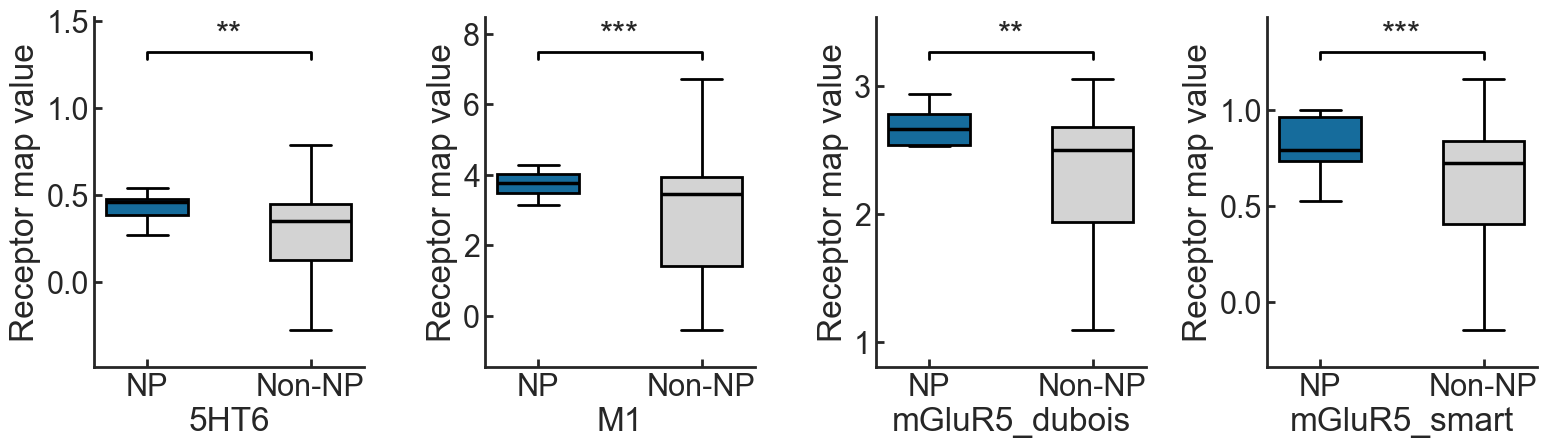

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
# ==============================
# 1. 读入你的数据（示例）
# ==============================
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/corr_neuromaps_np_regions/compare_np_non_regions_neurotransmitter.csv',header=0,index_col=False)
df.columns = [
    '5HT6_group1','M1_group1',
    'mGluR5_dubois_group1','mGluR5_smart_group1',
    '5HT6_group2','M1_group2',
    'mGluR5_dubois_group2','mGluR5_smart_group2'    
]
# ==============================
# 2. 变量配置（你只需要改这里）
# ==============================
var_pairs = {
    '5HT6': ('5HT6_group1', '5HT6_group2'),
    'M1': ('M1_group1', 'M1_group2'),
    'mGluR5_dubois': ('mGluR5_dubois_group1', 'mGluR5_dubois_group2'),
    'mGluR5_smart': ('mGluR5_smart_group1', 'mGluR5_smart_group2')
}

def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'
# ==============================
# 3. 画 4 个成对 boxplot
# ==============================
sns.set(font_scale=2, style="ticks")
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
box_colors = ['#0072B2', '#D3D3D3'] 
for i, (var_name, (colA, colB)) in enumerate(var_pairs.items()):

    dataA = df[colA].dropna()
    dataB = df[colB].dropna()

    plot_df = pd.DataFrame({
        'Group': ['NP'] * len(dataA) + ['Non-NP'] * len(dataB),
        'Receptor density': np.concatenate([dataA, dataB])
    })

    sns.boxplot(
        x='Group', y='Receptor density', data=plot_df,
        ax=axes[i],
        palette=box_colors,
        width=0.5,
        showcaps=True,
        boxprops=dict(edgecolor='black', linewidth=2),
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops={'color':'black', 'linewidth':2},
        capprops={'color':'black', 'linewidth':2},
        showfliers=False
    )
    
    for patch in axes[i].artists:
        patch.set_alpha(0.8)
    
    #sns.stripplot(
     #   x='Group',
      #  y='Receptor density',
      #  data=plot_df,
      #  ax=axes[i],
      #  color='black',
      #  size=4,
      #  jitter=0.2,
      #  alpha=0.5
   # )
    # ==============================
    # 4. 成对统计检验（welch t-test）
    # ==============================
    t, p = ttest_ind(dataA, dataB,equal_var=False)
    # 显著性标注
    y_max = max(dataA.max(), dataB.max())
    y_min = min(dataA.min(), dataB.min())
    y_range = y_max - y_min
    axes[i].set_ylim(
    y_min - 0.15 * y_range,
    y_max + 0.25 * y_range
    )
    h = y_max + 0.08 * y_range
    barh = 0.03 * y_range
    axes[i].plot([0, 0, 1, 1], [h, h + barh, h + barh, h],
             lw=2, c='black')
    axes[i].text(0.5, h + barh, p_to_star(p), ha='center', va='bottom')
    #axes[i].set_title(f'{var_name}\n p = {p:.3g}')
    axes[i].set_xlabel(var_name)
    axes[i].tick_params(axis='both',which='major',width=2,length=6,direction='in')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_linewidth(2)
    axes[i].spines['bottom'].set_linewidth(2)
    axes[i].set_ylabel('Receptor map value')
    
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/corr_neuromaps_np_regions/compare_np_non_regions_neurotransmitter.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/730808948.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['NP', 'Non-NP'], fontsize=18)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/730808948.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['NP', 'Non-NP'], fontsize=18)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/730808948.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['NP', 'Non-NP'], fontsize=18)


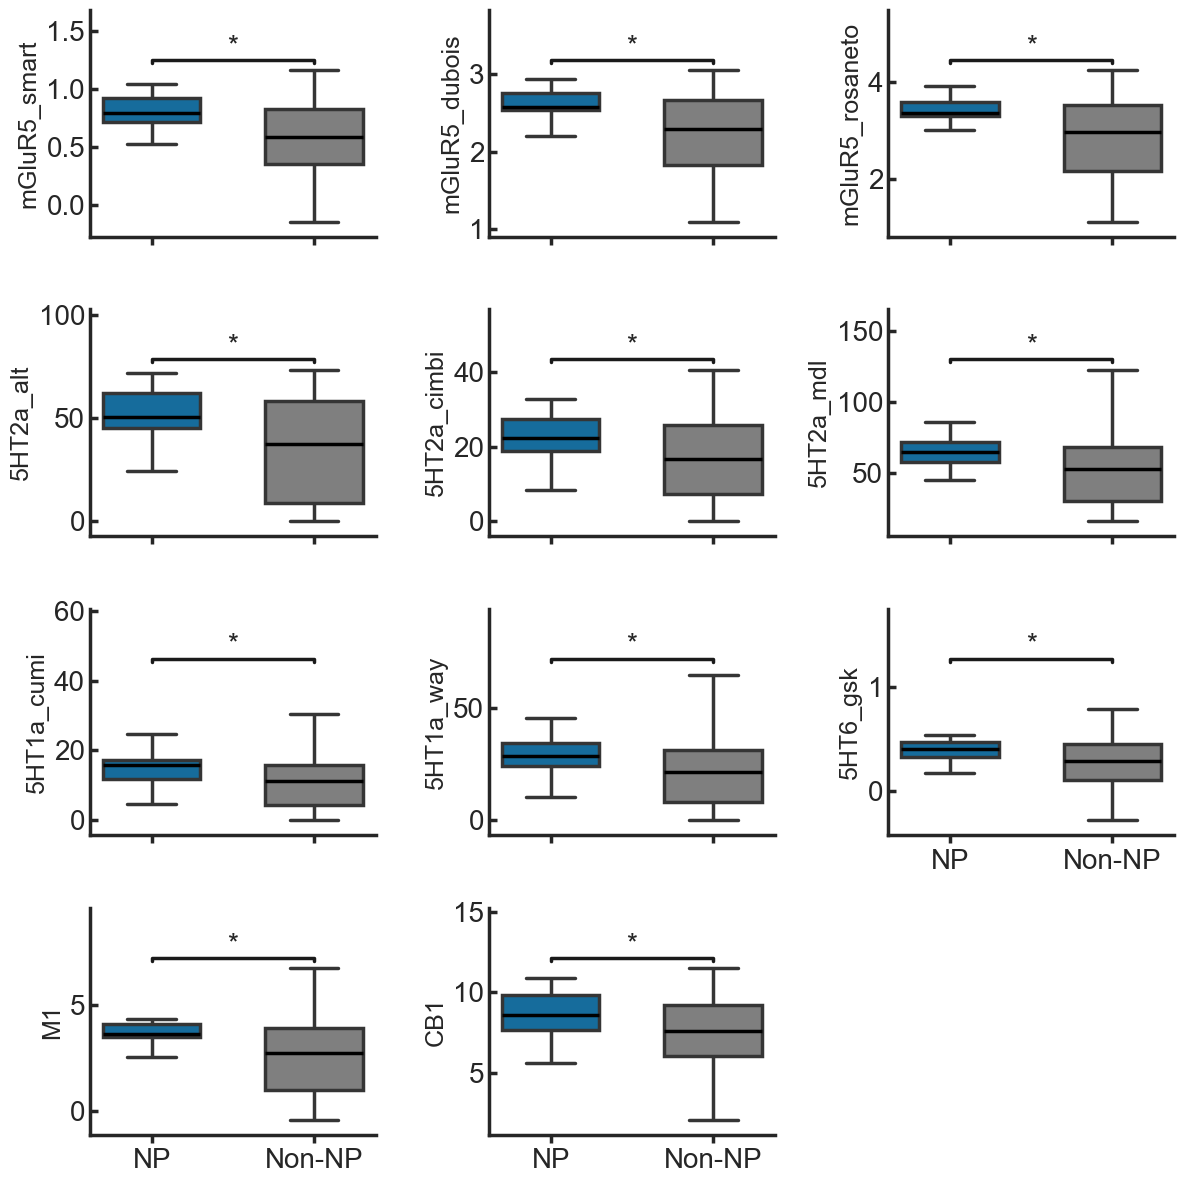

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib as mpl

# --- 1. 基础配置与函数定义 ---
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

def p_to_star(p):
    if p <= 0.001: return '***'
    elif p <= 0.01: return '**'
    elif p <= 0.05: return '*'
    else: return 'n.s.'

# --- 2. 数据读取与列名对齐 ---
# 请确保路径正确
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/corr_neuromaps_np_regions/permutation_results_values.csv', header=0)

df.columns = [
    '5HT1a_cumi_group1','5HT1a_way_group1','5HT2a_alt_group1','5HT2a_cimbi_group1','5HT2a_mdl_group1','5HT6_gsk_group1','CB1_group1','M1_group1','mGluR5_rosaneto_group1','mGluR5_dubois_group1','mGluR5_smart_group1',
    '5HT1a_cumi_group2','5HT1a_way_group2','5HT2a_alt_group2','5HT2a_cimbi_group2','5HT2a_mdl_group2','5HT6_gsk_group2','CB1_group2','M1_group2','mGluR5_rosaneto_group2','mGluR5_dubois_group2','mGluR5_smart_group2']

var_pairs = {
    'mGluR5_smart': ('mGluR5_smart_group1', 'mGluR5_smart_group2'),
    'mGluR5_dubois': ('mGluR5_dubois_group1', 'mGluR5_dubois_group2'),
    'mGluR5_rosaneto': ('mGluR5_rosaneto_group1', 'mGluR5_rosaneto_group2'),
    '5HT2a_alt':  ('5HT2a_alt_group1','5HT2a_alt_group2'),
    '5HT2a_cimbi':  ('5HT2a_cimbi_group1','5HT2a_cimbi_group2'),
    '5HT2a_mdl':  ('5HT2a_mdl_group1','5HT2a_mdl_group2'),
    '5HT1a_cumi': ('5HT1a_cumi_group1','5HT1a_cumi_group2'),
    '5HT1a_way':  ('5HT1a_way_group1','5HT1a_way_group2'),
    '5HT6_gsk': ('5HT6_gsk_group1', '5HT6_gsk_group2'),
    'M1': ('M1_group1', 'M1_group2'),
    'CB1': ('CB1_group1', 'CB1_group2')
    
    
}

box_colors = ['#0072B2', '#7F7F7F'] 

# --- 3. 绘图 ---
sns.set(style="ticks")
fig, axes = plt.subplots(4, 3, figsize=(12, 12)) # 增加高度以适应 4 行
axes_flat = axes.flatten()

# 获取总对数
total_vars = len(var_pairs)

for i, (var_name, (colA, colB)) in enumerate(var_pairs.items()):
    ax = axes_flat[i]
    dataA = df[colA].dropna()
    dataB = df[colB].dropna()

    plot_df = pd.DataFrame({
        'Region': ['NP'] * len(dataA) + ['Non-NP'] * len(dataB),
        'Val': np.concatenate([dataA, dataB])
    })

    sns.boxplot(
        x='Region', y='Val', data=plot_df,
        ax=ax,
        hue='Region', # 避免新版 Seaborn 警告
        palette=box_colors,
        width=0.6,
        linewidth=2.5,
        showfliers=False,
        showmeans=True, meanline=True,
        medianprops={'visible': False},
        meanprops={'color': 'black', 'ls': '-', 'lw': 2.5}
        #saturation=1,
        #legend=False
    )

    # 显著性计算
    t, p = ttest_ind(dataA, dataB, equal_var=False)
    p = 0.03 # 校正后的p值

    # 动态 Y 轴范围
    y_min, y_max = plot_df['Val'].min(), plot_df['Val'].max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.4 * y_range)

    # 标注星号
    h = y_max + 0.05 * y_range
    ax.plot([0, 0, 1, 1], [h, h + 0.02*y_range, h + 0.02*y_range, h], lw=2.5, c='k')
    ax.text(0.5, h + 0.02*y_range, p_to_star(p), ha='center', va='bottom', fontsize=20)

    # 标签设置
    ax.set_ylabel(var_name, fontsize=18)
    ax.set_xlabel('')
    
    # 精确控制 X 轴刻度：只有最下面一排的图（第 9, 10, 11 个）显示 NP/Non-NP
    # 在 4x3 布局中，最后三个位置索引是 9, 10, 11。但因为只有 11 个变量，
    # 逻辑应该是：如果下方没有图了，就显示刻度。
    if i < 8: # 前两行及第三行第一个隐藏
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(['NP', 'Non-NP'], fontsize=18)

    # 边框美化
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    for spine in ax.spines.values(): spine.set_linewidth(2.5)
    ax.tick_params(width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y',direction='in')
# --- 4. 清理多余的子图 ---
# 隐藏第 12 个空白子图
if len(axes_flat) > total_vars:
    for j in range(total_vars, len(axes_flat)):
        axes_flat[j].axis('off')

plt.tight_layout(h_pad=2, w_pad=2)
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/corr_neuromaps_np_regions/compare_np_non_regions_permutation.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/758487222.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/758487222.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/758487222.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/758487222.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

Baseline NP: U-stat=474.0, p-value=0.0000, n1=251, n2=39
popular: U-stat=3299.0, p-value=0.0012, n1=250, n2=39
panic attacks: U-stat=6088.0, p-value=0.0125, n1=250, n2=39
unhappy: U-stat=6219.0, p-value=0.0056, n1=250, n2=39
problem: U-stat=6088.0, p-value=0.0125, n1=250, n2=39
distract: U-stat=5940.0, p-value=0.0283, n1=250, n2=39
stomach-ache: U-stat=5827.0, p-value=0.0500, n1=250, n2=39
fears: U-stat=5802.0, p-value=0.0563, n1=250, n2=39


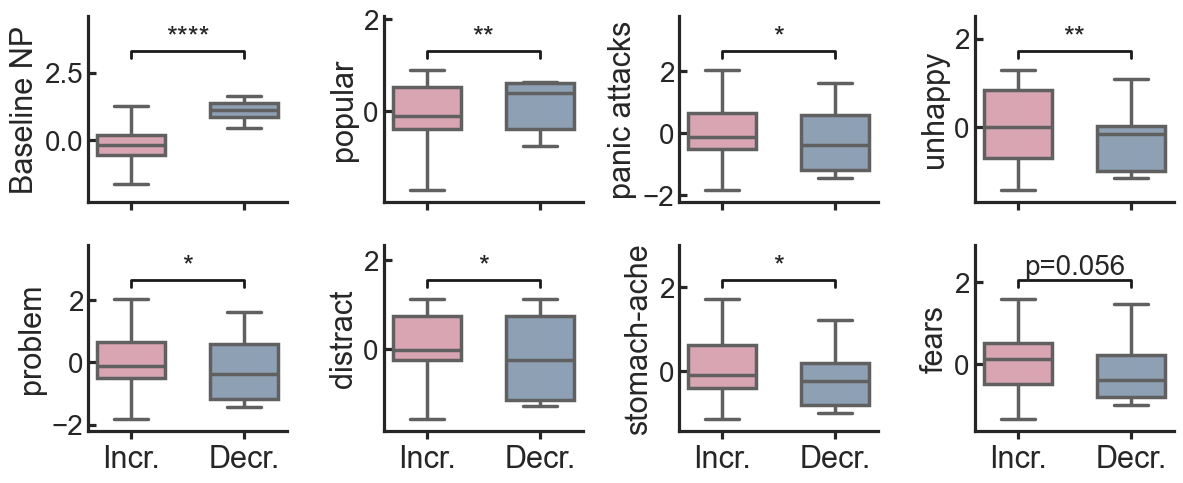

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu  # 修改此处
import matplotlib as mpl
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig3/compare_subgroup_np_beha_symp.csv')

# 设置全局字体
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

def p_to_star(p):
    if p < 0.0001: return '****'
    el p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif 0.05 <= p < 0.10: return f'p={p:.3f}' # 对于边缘显著的结果显示具体数值
    else: return 'n.s.'

# ==============================
# 2. 变量配置
# ==============================
var_pairs = {
    'Baseline NP': ('baseline NP_group1', 'baseline NP_group2'),
    'popular': ('spopular_group1', 'spopular_group2'),
    'panic attacks': ('sebddiff_group1', 'sebddiff_group2'), 
    'unhappy': ('sunhappy_group1', 'sunhappy_group2'),
    'problem': ('sebddiff_group1', 'sebddiff_group2'),
    'distract': ('sdistrac_group1', 'sdistrac_group2'),
    'stomach-ache': ('ssomatic_group1', 'ssomatic_group2'),
    'fears': ('safraid_group1', 'safraid_group2'),
}

box_colors = ['#D9A5B3', '#8DA0B4']

# ==============================
# 3. 绘图与统计
# ==============================
sns.set(style="ticks")
fig, axes = plt.subplots(2, 4, figsize=(12, 5)) 
axes = axes.flatten()

for i, (var_name, (colA, colB)) in enumerate(var_pairs.items()):
    ax = axes[i]
    
    # 获取数据并直接 dropna (不考虑缺失值参与统计)
    dataA = df[colA].dropna()
    dataB = df[colB].dropna()

    plot_df = pd.DataFrame({
        'Group': ['Increased'] * len(dataA) + ['Decreased'] * len(dataB),
        'Value': np.concatenate([dataA, dataB])
    })

    # 绘制 Boxplot
    sns.boxplot(
        x='Group', y='Value', data=plot_df, ax=ax,
        palette=box_colors, width=0.6, linewidth=2.5,
        showfliers=False, saturation=1
    )

    # --- 使用 Mann-Whitney U 检验 ---
    # alternative='two-sided' 是标准做法
    stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
    
    # 打印结果以便你核对具体数值
    print(f"{var_name}: U-stat={stat:.1f}, p-value={p:.4f}, n1={len(dataA)}, n2={len(dataB)}")

    # 标注处理
    y_min, y_max = plot_df['Value'].min(), plot_df['Value'].max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.45 * y_range)

    h = y_max + 0.1 * y_range
    bar_h = 0.06 * y_range
    ax.plot([0, 0, 1, 1], [h, h + bar_h, h + bar_h, h], lw=2, c='k')
    ax.text(0.5, h + bar_h, p_to_star(p), ha='center', va='bottom', fontsize=20)
    
    # 坐标轴格式
    ax.set_ylabel(var_name, fontsize=22)
    ax.set_xlabel('')
    #ax.tick_params(axis='both', which='major', width=2.5, length=6, direction='in', labelsize=20)
    ax.tick_params(axis='both', which='major', width=2.3, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    if i < 4:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(['Incr.', 'Decr.'], fontsize=22)

    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    for spine in ax.spines.values(): spine.set_linewidth(2.3)

plt.tight_layout(h_pad=2, w_pad=1.5)
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_subgroup_np_beha_mw.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/3983236517.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df_sub, x='Diseased', y='Neg_NP',


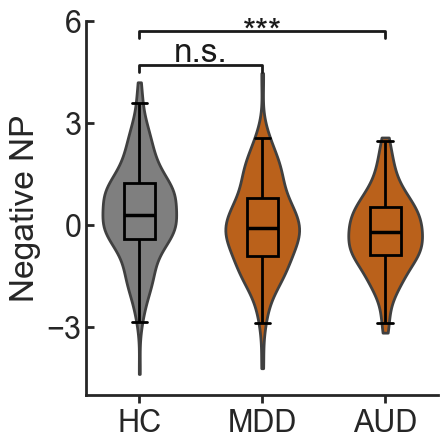

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/pos_neg_np_stratify_resi_without_ed.csv')
df_sub = df[df['Diseased'].isin(['HC', 'MDD', 'AUD'])]
# 配色
palette = {
    'HC': (127/255, 127/255, 127/255),
    'MDD': (213/255, 94/255, 0/255),
    'AUD': (213/255, 94/255, 0/255)
}
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
des_order = ['HC','MDD','AUD']

# Violin plot + boxplot
ax = sns.violinplot(data=df_sub, x='Diseased', y='Neg_NP',
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6,alpha=1)
sns.boxplot(
    data=df_sub,
    x='Diseased',
    y='Neg_NP',
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')
# 添加显著性星号
group1 = df[df['Diseased'] == 'HC']['Neg_NP']
group2 = df[df['Diseased'] == 'MDD']['Neg_NP']
group3 = df[df['Diseased'] == 'AUD']['Neg_NP']


def add_sigline(ax, x1, x2, y, h, stars, color='k', lw=2, fs=24, text_offset=0.1):
    """
    ax          : 绘图对象
    x1, x2      : 两组的横坐标索引
    y           : 竖线的起始高度
    h           : 竖线向上延伸的高度
    stars       : 显著性标记 ('*', 'n.s.' 等)
    text_offset : 显著性符号与横线之间的间距 (正值向上，负值向下)
    """
    # 绘制 [ |--- ] 形状的线
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    
    # 绘制文字
    # y+h 是横线的高度，加上 text_offset 即可自主调节距离
    ax.text((x1 + x2) * .5, 
            y + h + text_offset, 
            stars, 
            ha='center', 
            va='bottom', # 底部对齐，确保 offset 是从文字底部算起
            color=color, 
            fontsize=fs)
    
add_sigline(ax, 0, 1, 4.5, 0.2, "n.s.", text_offset=-0.1)   # HC vs MDD
add_sigline(ax, 0, 2, 5.5, 0.2, "***", text_offset=-0.5)    # HC vs AUD
# 如果觉得太近，就调大 text_offset，比如 0.2 或 0.5


ax.set_ylim(-5, 6)
ax.set_yticks([-3,0,3,6])
ax.set_xticks(range(len(des_order)))
ax.set_xticklabels(des_order)

plt.ylabel('Negative NP')
plt.xlabel('')

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/SI_compare_neg_np_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/1850251320.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df_sub, x='Diseased', y='Pos_NP',


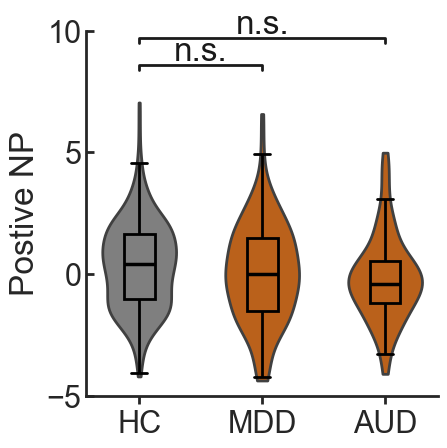

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/pos_neg_np_stratify_resi_without_ed.csv')
df_sub = df[df['Diseased'].isin(['HC', 'MDD', 'AUD'])]
# 配色
palette = {
    'HC': (127/255, 127/255, 127/255),
    'MDD': (213/255, 94/255, 0/255),
    'AUD': (213/255, 94/255, 0/255)
}
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
des_order = ['HC','MDD','AUD']

# Violin plot + boxplot
ax = sns.violinplot(data=df_sub, x='Diseased', y='Pos_NP',
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6,alpha=1)
sns.boxplot(
    data=df_sub,
    x='Diseased',
    y='Pos_NP',
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')
# 添加显著性星号
group1 = df[df['Diseased'] == 'HC']['Pos_NP']
group2 = df[df['Diseased'] == 'MDD']['Pos_NP']
group3 = df[df['Diseased'] == 'AUD']['Pos_NP']

def add_sigline(ax, x1, x2, y, h, stars, color='k', lw=2, fs=24, text_offset=0.1):
    """
    ax          : 绘图对象
    x1, x2      : 两组的横坐标索引
    y           : 竖线的起始高度
    h           : 竖线向上延伸的高度
    stars       : 显著性标记 ('*', 'n.s.' 等)
    text_offset : 显著性符号与横线之间的间距 (正值向上，负值向下)
    """
    # 绘制 [ |--- ] 形状的线
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    
    # 绘制文字
    # y+h 是横线的高度，加上 text_offset 即可自主调节距离
    ax.text((x1 + x2) * .5, 
            y + h + text_offset, 
            stars, 
            ha='center', 
            va='bottom', # 底部对齐，确保 offset 是从文字底部算起
            color=color, 
            fontsize=fs)

# --- 调用示例 ---
# 如果觉得太近，就调大 text_offset，比如 0.2 或 0.5
add_sigline(ax, 0, 1, 8.4, 0.2, "n.s.", text_offset=-0.1)
add_sigline(ax, 0, 2, 9.5, 0.2, "n.s.", text_offset=-0.1)

ax.set_ylim(-5, 10)
ax.set_yticks([-5,0,5,10])
ax.set_xticks(range(len(des_order)))
ax.set_xticklabels(des_order)

plt.ylabel('Postive NP')
plt.xlabel('')

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/SI_compare_pos_np_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62140/2477770979.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df_sub, x='Diseased', y='NP factor',


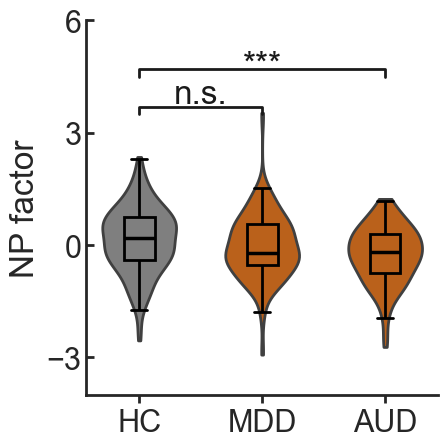

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/pos_neg_np_stratify_resi_without_ed.csv')
df_sub = df[df['Diseased'].isin(['HC', 'MDD', 'AUD'])]
# 配色
palette = {
    'HC': (127/255, 127/255, 127/255),
    'MDD': (213/255, 94/255, 0/255),
    'AUD': (213/255, 94/255, 0/255)
}
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
des_order = ['HC','MDD','AUD']

# Violin plot + boxplot
ax = sns.violinplot(data=df_sub, x='Diseased', y='NP factor',
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6,alpha=1)
sns.boxplot(
    data=df_sub,
    x='Diseased',
    y='NP factor',
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')
# 添加显著性星号
group1 = df[df['Diseased'] == 'HC']['NP factor']
group2 = df[df['Diseased'] == 'MDD']['NP factor']
group3 = df[df['Diseased'] == 'AUD']['NP factor']

def add_sigline(ax, x1, x2, y, h, stars, color='k', lw=2, fs=24, text_offset=0.1):
    """
    ax          : 绘图对象
    x1, x2      : 两组的横坐标索引
    y           : 竖线的起始高度
    h           : 竖线向上延伸的高度
    stars       : 显著性标记 ('*', 'n.s.' 等)
    text_offset : 显著性符号与横线之间的间距 (正值向上，负值向下)
    """
    # 绘制 [ |--- ] 形状的线
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c=color)
    
    # 绘制文字
    # y+h 是横线的高度，加上 text_offset 即可自主调节距离
    ax.text((x1 + x2) * .5, 
            y + h + text_offset, 
            stars, 
            ha='center', 
            va='bottom', # 底部对齐，确保 offset 是从文字底部算起
            color=color, 
            fontsize=fs)

# --- 调用示例 ---
# 如果觉得太近，就调大 text_offset，比如 0.2 或 0.5
add_sigline(ax, 0, 1, 3.5, 0.2, "n.s.", text_offset=-0.1)   # HC vs mdd
add_sigline(ax, 0, 2, 4.5, 0.2, "***", text_offset=-0.3)    # HC vs aud

ax.set_ylim(-4, 6)
ax.set_yticks([-3,0,3,6])
ax.set_xticks(range(len(des_order)))
ax.set_xticklabels(des_order)

plt.ylabel('NP factor')
plt.xlabel('')

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/SI_compare_np_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

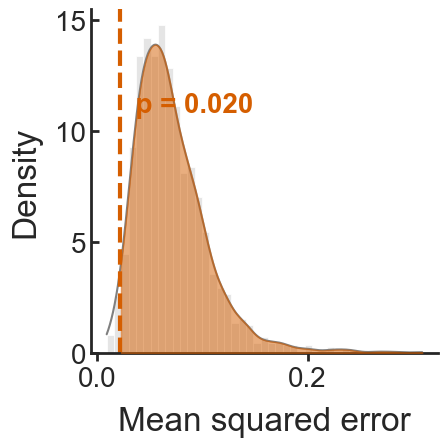

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mse_null_dist.csv')

# 提取零分布和真实观测值
# 假设列名分别为 'null_values' 和 'actual_value'
null_dist = df['null_values_mdd'].dropna().values
observed_stat = df['actual_value_mdd'].iloc[0] # 获取真实值

# 2. 计算精确的置换 P 值
# P = (大于等于真实值的随机次数) / 总随机次数
p_value = np.sum(null_dist <= observed_stat) / len(null_dist)

# 3. 开始绘图
plt.figure(figsize=(5, 5))
sns.set_style("ticks")

# 绘制零分布 (使用 Hist + KDE 结合，更有科研感)
sns.histplot(null_dist, kde=True, stat="density", color="gray", alpha=0.2, 
             edgecolor='white', linewidth=0.5, label='Null Distribution')

# 绘制真实观测值的垂线
plt.axvline(observed_stat, color='#D55E00', linestyle='--', linewidth=3, 
            label=f'Observed (p = {p_value:.3f})')

# 4. 填充显著性区域 (关键修复版本)
ax = plt.gca()
kde_line = ax.get_lines()[0]
x_kde, y_kde = kde_line.get_data()
x_kde, y_kde = np.array(x_kde), np.array(y_kde) # 确保是 numpy 数组

plt.fill_between(x_kde, y_kde, where=(x_kde >= observed_stat), 
                 color='#D55E00', alpha=0.5, zorder=3)

# 5. 视觉优化
plt.xlabel('Mean squared error', fontsize=24, labelpad=10)
plt.ylabel('Density', fontsize=24, labelpad=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# 移除边框并加粗
sns.despine()
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')

# 在图上直接标注 P 值文字
plt.text(observed_stat, plt.ylim()[1]*0.7, f'  p = {p_value:.3f}', 
         color='#D55E00', fontweight='bold', fontsize=20)

#plt.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# 保存
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/SI_permutation_test_mdd.png', dpi=300)
plt.show()

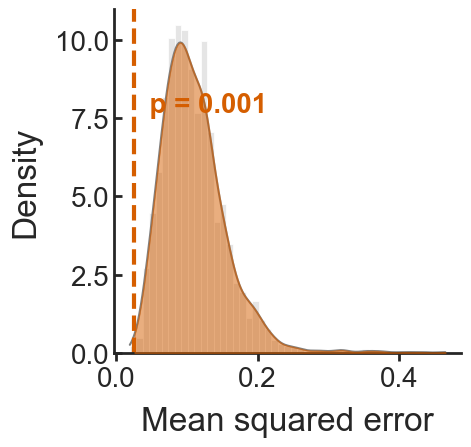

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mse_null_dist.csv')

# 提取零分布和真实观测值
# 假设列名分别为 'null_values' 和 'actual_value'
null_dist = df['null_values_aud'].dropna().values
observed_stat = df['actual_value_aud'].iloc[0] # 获取真实值

# 2. 计算精确的置换 P 值
# P = (大于等于真实值的随机次数) / 总随机次数
p_value = np.sum(null_dist <= observed_stat) / len(null_dist)

# 3. 开始绘图
plt.figure(figsize=(5, 5))
sns.set_style("ticks")

# 绘制零分布 (使用 Hist + KDE 结合，更有科研感)
sns.histplot(null_dist, kde=True, stat="density", color="gray", alpha=0.2, 
             edgecolor='white', linewidth=0.5, label='Null Distribution')

# 绘制真实观测值的垂线
plt.axvline(observed_stat, color='#D55E00', linestyle='--', linewidth=3, 
            label=f'Observed (p = {p_value:.3f})')

# 4. 填充显著性区域 (关键修复版本)
ax = plt.gca()
kde_line = ax.get_lines()[0]
x_kde, y_kde = kde_line.get_data()
x_kde, y_kde = np.array(x_kde), np.array(y_kde) # 确保是 numpy 数组

plt.fill_between(x_kde, y_kde, where=(x_kde >= observed_stat), 
                 color='#D55E00', alpha=0.5, zorder=3)

# 5. 视觉优化
plt.xlabel('Mean squared error', fontsize=24, labelpad=10)
plt.ylabel('Density', fontsize=24, labelpad=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# 移除边框并加粗
sns.despine()
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')

# 在图上直接标注 P 值文字
plt.text(observed_stat, plt.ylim()[1]*0.7, f'  p = {p_value:.3f}', 
         color='#D55E00', fontweight='bold', fontsize=20)

#plt.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# 保存
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/SI_permutation_test_aud.png', dpi=300)
plt.show()

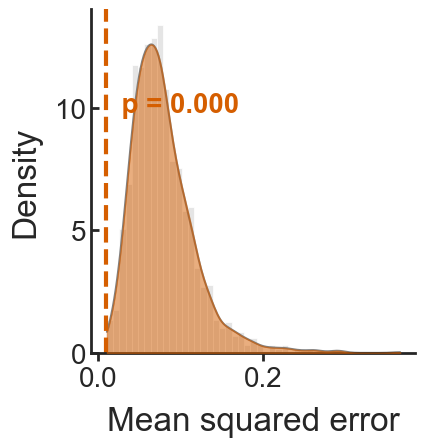

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mse_null_dist.csv')

# 提取零分布和真实观测值
# 假设列名分别为 'null_values' 和 'actual_value'
null_dist = df['null_values_hc01'].dropna().values
observed_stat = df['actual_value_hc01'].iloc[0] # 获取真实值

# 2. 计算精确的置换 P 值
# P = (大于等于真实值的随机次数) / 总随机次数
p_value = np.sum(null_dist <= observed_stat) / len(null_dist)

# 3. 开始绘图
plt.figure(figsize=(5, 5))
sns.set_style("ticks")

# 绘制零分布 (使用 Hist + KDE 结合，更有科研感)
sns.histplot(null_dist, kde=True, stat="density", color="gray", alpha=0.2, 
             edgecolor='white', linewidth=0.5, label='Null Distribution')

# 绘制真实观测值的垂线
plt.axvline(observed_stat, color='#D55E00', linestyle='--', linewidth=3, 
            label=f'Observed (p = {p_value:.3f})')

# 4. 填充显著性区域 (关键修复版本)
ax = plt.gca()
kde_line = ax.get_lines()[0]
x_kde, y_kde = kde_line.get_data()
x_kde, y_kde = np.array(x_kde), np.array(y_kde) # 确保是 numpy 数组

plt.fill_between(x_kde, y_kde, where=(x_kde >= observed_stat), 
                 color='#D55E00', alpha=0.5, zorder=3)

# 5. 视觉优化
plt.xlabel('Mean squared error', fontsize=24, labelpad=10)
plt.ylabel('Density', fontsize=24, labelpad=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# 移除边框并加粗
sns.despine()
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')

# 在图上直接标注 P 值文字
plt.text(observed_stat, plt.ylim()[1]*0.7, f'  p = {p_value:.3f}', 
         color='#D55E00', fontweight='bold', fontsize=20)

#plt.legend(frameon=False, loc='upper right', fontsize=20)
plt.tight_layout()

# 保存
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/SI_permutation_test_hc01.png', dpi=300)
plt.show()

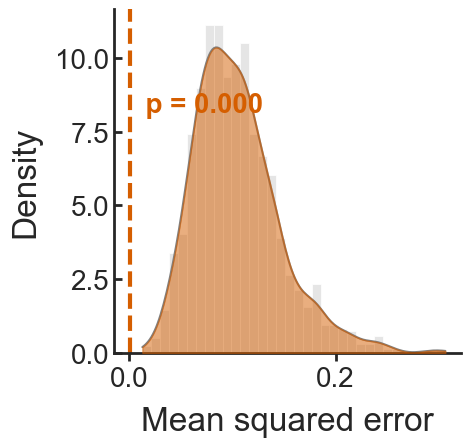

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mse_null_dist.csv')

# 提取零分布和真实观测值
# 假设列名分别为 'null_values' 和 'actual_value'
null_dist = df['null_values_hc02'].dropna().values
observed_stat = df['actual_value_hc02'].iloc[0] # 获取真实值

# 2. 计算精确的置换 P 值
# P = (小于等于真实值的随机次数) / 总随机次数
p_value = np.sum(null_dist <= observed_stat) / len(null_dist)

# 3. 开始绘图
plt.figure(figsize=(5, 5))
sns.set_style("ticks")

# 绘制零分布 (使用 Hist + KDE 结合，更有科研感)
sns.histplot(null_dist, kde=True, stat="density", color="gray", alpha=0.2, 
             edgecolor='white', linewidth=0.5, label='Null Distribution')

# 绘制真实观测值的垂线
plt.axvline(observed_stat, color='#D55E00', linestyle='--', linewidth=3, 
            label=f'Observed (p = {p_value:.3f})')

# 4. 填充显著性区域 (关键修复版本)
ax = plt.gca()
kde_line = ax.get_lines()[0]
x_kde, y_kde = kde_line.get_data()
x_kde, y_kde = np.array(x_kde), np.array(y_kde) # 确保是 numpy 数组

plt.fill_between(x_kde, y_kde, where=(x_kde >= observed_stat), 
                 color='#D55E00', alpha=0.5, zorder=3)

# 5. 视觉优化
plt.xlabel('Mean squared error', fontsize=24, labelpad=10)
plt.ylabel('Density', fontsize=24, labelpad=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# 移除边框并加粗
sns.despine()
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')

# 在图上直接标注 P 值文字
plt.text(observed_stat, plt.ylim()[1]*0.7, f'  p = {p_value:.3f}', 
         color='#D55E00', fontweight='bold', fontsize=20)

#plt.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# 保存
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/SI_permutation_test_hc02.png', dpi=300)
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/4067896037.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['np_factor_2_cov_sex_site_hd', 'Simulated NP_cov_sex_site_hd'],
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/4067896037.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Empirical', 'Simulated'], fontsize=20)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/4067896037.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['np_factor_2_cov

========== Statistical Report: HC ==========
Paired T-test: t = 0.9432, p = 0.3489
========== Statistical Report: High-symptom ==========
Paired T-test: t = -0.9320, p = 0.3539
========== Statistical Report: Patient ==========
Paired T-test: t = 0.0157, p = 0.9875


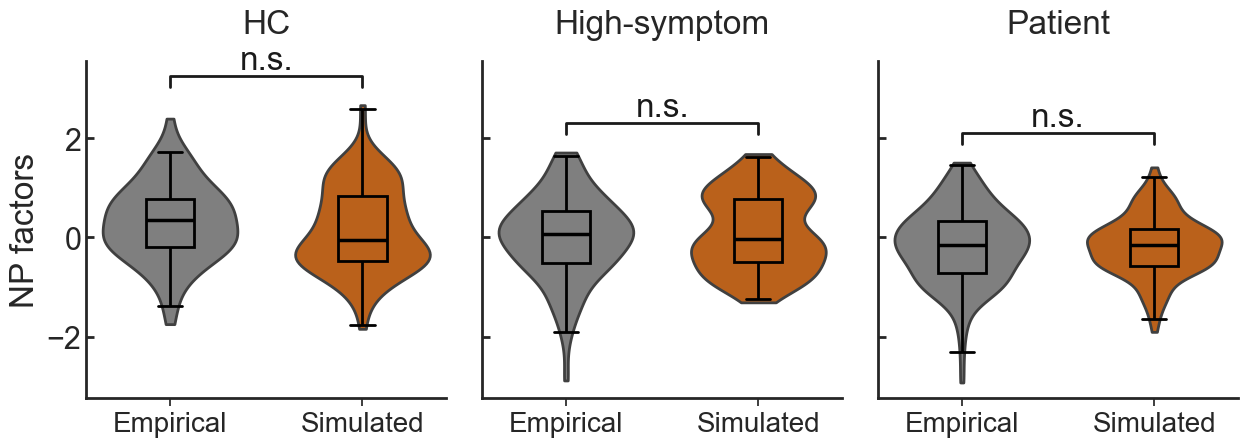

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel  # 建议使用配对T检验，因为模拟值是基于同一个体生成的

# 1. 数据加载与预处理
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mani_ampa_gaba_subs3.csv')

# 这里的 palette 对应的是变量名
palette = {
    'np_factor_2_cov_sex_site_hd': (127/255, 127/255, 127/255),       # 灰色代表真实值
    'Simulated NP_cov_sex_site_hd': (213/255, 94/255, 0/255) # 橙色代表模拟值
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks")
plt.rcParams['font.sans-serif'] = ['Arial']

def draw_internal_comparison(ax, df_group, group_name):
    """
    针对单个组绘制 np vs simulate np 的比较
    """
    # 将数据从宽表转为长表 (Melt)
    # 假设列名就是 'np' 和 'simulate np'
    df_melt = df_group.melt(value_vars=['np_factor_2_cov_sex_site_hd', 'Simulated NP_cov_sex_site_hd'], 
                            var_name='Type', value_name='Score')

    # 绘制小提琴图
    sns.violinplot(data=df_melt, x='Type', y='Score', order=['np_factor_2_cov_sex_site_hd', 'Simulated NP_cov_sex_site_hd'],
                   palette=palette, inner=None, linewidth=2, cut=0.2, width=0.7, ax=ax)
    
    # 叠加箱线图
    sns.boxplot(data=df_melt, x='Type', y='Score', order=['np_factor_2_cov_sex_site_hd', 'Simulated NP_cov_sex_site_hd'],
                width=0.25, showcaps=True, showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(color='black', linewidth=2),
                capprops=dict(color='black', linewidth=2), ax=ax)

    # 统计计算 (因为是同一个人的模拟，建议用配对 T 检验 ttest_rel)
    v1 = df_group['np_factor_2_cov_sex_site_hd'].dropna()
    v2 = df_group['Simulated NP_cov_sex_site_hd'].dropna()
    stat, p_val = ttest_rel(v1, v2)
    
    # 显著性标注
    if p_val < 0.001: sig_text = "***"
    elif p_val < 0.01: sig_text = "**"
    elif p_val < 0.05: sig_text = "*"
    else: sig_text = "n.s."
    # --- 打印统计结果到控制台 ---
    print(f"{'='*10} Statistical Report: {group_name} {'='*10}")
    
    print(f"Paired T-test: t = {stat:.4f}, p = {p_val:.4f}")
    # 标注线高度控制
    y_max = df_melt['Score'].max()
    line_y = y_max + (df_melt['Score'].max() - df_melt['Score'].min()) * 0.1
    line_h = (df_melt['Score'].max() - df_melt['Score'].min()) * 0.05
    
    ax.plot([0, 0, 1, 1], [line_y, line_y + line_h, line_y + line_h, line_y], lw=2, c='k')
    ax.text(0.5, line_y + line_h, sig_text, ha='center', va='bottom', color='k', fontsize=24)

    # 细节美化
    ax.set_title(group_name, fontsize=24, pad=20)
    ax.set_ylabel('NP factors', fontsize=24)
    ax.set_xlabel('')
    ax.set_xticklabels(['Empirical', 'Simulated'], fontsize=20)
    ax.tick_params(axis='y', direction='in', length=6, width=2)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# 2. 获取三个组的名字 (假设 Group 列里有三个唯一值)
group_list = df['Group'].unique() 
# 如果你想手动指定顺序，可以写成 group_list = ['HC', 'High-symptom', 'Patient']

# 3. 创建画布并循环绘图
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True) # sharey=True 方便横向对比

for i, g_name in enumerate(group_order):
    if i < 3: # 确保不超过子图数量
        df_sub = df[df['Group'] == g_name]
        draw_internal_comparison(axes[i], df_sub, g_name)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/internal_model_validation.png', dpi=300)
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Empirical vs. Simulated: t-test paired samples, P_val:7.775e-03 t=-4.292e+00

Paired T-test Result:
t = -4.2919, p = 0.0078


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/1070276130.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Empirical', 'Simulated'], fontsize=24)


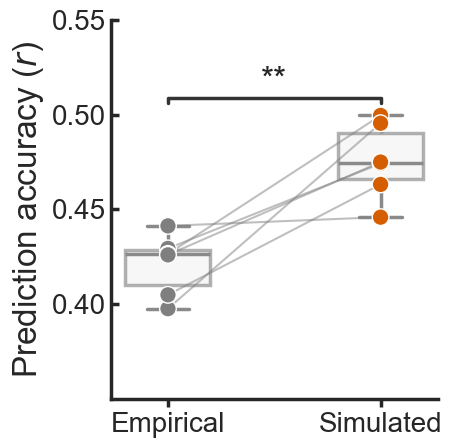

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import ttest_rel

# 1. 加载数据
file_path = '/Users/yunman/Desktop/submission/figures/fig4/cpm_task_perf_results/compare_simulated_emp_r.csv'
df = pd.read_csv(file_path)

# 2. 配置颜色
type_palette = {'Empirical': '#7F7F7F', 'Simulated': '#D55E00'} 
box_color = '#E6E6E6'

def draw_empirical_simulated_paired(df, save_name='SI_prediction_task_emp_sim'):
    """
    输入 df 包含 'empirical' 和 'simulated' 两列
    """
    df = df.copy()
    
    
    # 给数据加上 Subject ID 确保连线正确
    if 'Subject' not in df.columns:
        df['Subject'] = range(len(df))

    # --- Melt 数据 ---
    df_long = df.melt(id_vars=['Subject'], value_vars=['empirical', 'simulated'], 
                      var_name='Type', value_name='Score')
    
    df_long['Type'] = df_long['Type'].replace({'empirical': 'Empirical', 'simulated': 'Simulated'})
    order = ['Empirical', 'Simulated']

    # --- 开始绘图 ---
    fig, ax = plt.subplots(figsize=(5, 5))

    # 第一层：背景 Boxplot
    sns.boxplot(
        x='Type', y='Score', data=df_long, order=order, ax=ax,
        width=0.4, color=box_color, fliersize=0, linewidth=2.5,
        boxprops=dict(alpha=0.3, edgecolor='black'), zorder=1
    )

    # 第二层：个体内连线
    for subj in df['Subject'].unique():
        subj_data = df_long[df_long['Subject'] == subj]
        y_emp = subj_data.loc[subj_data['Type'] == 'Empirical', 'Score'].values[0]
        y_sim = subj_data.loc[subj_data['Type'] == 'Simulated', 'Score'].values[0]
        ax.plot([0, 1], [y_emp, y_sim], color='gray', alpha=0.5, lw=1.5, linestyle='-', zorder=2)

    # 第三层：散点 (使用 hue 避免 Seaborn 警告)
    sns.stripplot(
        x='Type', y='Score', data=df_long, order=order, ax=ax,
        hue='Type', palette=type_palette, jitter=False, size=12, alpha=1, 
        linewidth=1, edgecolor='white', zorder=3, legend=False
    )

    # --- 显著性标注 ---
    annotator = Annotator(ax, [("Empirical", "Simulated")], data=df_long, x='Type', y='Score', order=order)
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', fontsize=24, line_width=2.5)
    annotator.apply_and_annotate()

    # --- 打印配对 T 检验结果 ---
    stat, p_val = ttest_rel(df['empirical'], df['simulated'])
    print(f"\nPaired T-test Result:\nt = {stat:.4f}, p = {p_val:.4f}")

    # --- 细节美化 ---
    ax.set_ylabel('Prediction accuracy ($r$)', fontsize=24)
    ax.set_xlabel('')
    ax.set_xticklabels(['Empirical', 'Simulated'], fontsize=24)
    
    sns.despine()
    for spine in ax.spines.values(): spine.set_linewidth(2.5)
    
    ax.tick_params(axis='both', width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    ax.set_ylim(0.35, 0.55)
    ax.set_yticks([0.4,0.45,0.5,0.55])
    plt.tight_layout()
    plt.savefig(f'/Users/yunman/Desktop/submission/figures/fig4/{save_name}.png', dpi=300)
    plt.show()

# 执行函数
draw_empirical_simulated_paired(df)
    

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2008946504.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_ampa_np'],
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2008946504.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/2008946504.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_ampa_np'],
/var/fo

========== Statistical Report: HC ==========
Paired T-test: t = -7.5926, p = 0.0000
========== Statistical Report: High-symptom ==========
Paired T-test: t = -8.7360, p = 0.0000
========== Statistical Report: Patient ==========
Paired T-test: t = -18.5976, p = 0.0000


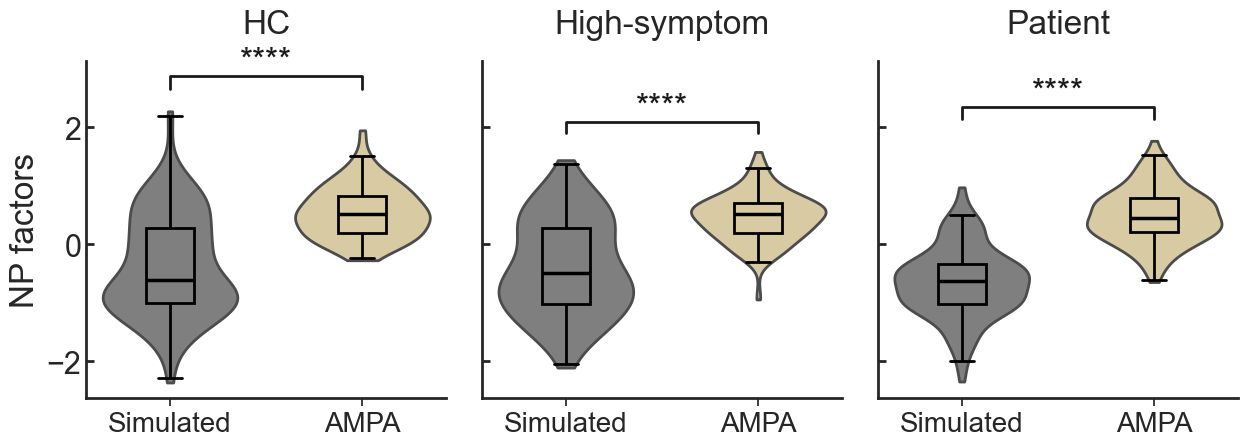

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel  # 建议使用配对T检验，因为模拟值是基于同一个体生成的

# 1. 数据加载与预处理
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mani_ampa_gaba_subs3.csv')

# 这里的 palette 对应的是变量名
palette = {
    'Simulated NP': (127/255, 127/255, 127/255),       # 灰色代表真实值
    'Manipulated_ampa_np': (225/255, 208/255, 154/255) # 橙色代表模拟值
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks")
plt.rcParams['font.sans-serif'] = ['Arial']

def draw_internal_comparison(ax, df_group, group_name):
    """
    针对单个组绘制 np vs simulate np 的比较
    """
    # 将数据从宽表转为长表 (Melt)
    # 假设列名就是 'np' 和 'simulate np'
    df_melt = df_group.melt(value_vars=['Simulated NP','Manipulated_ampa_np'], 
                            var_name='Type', value_name='Score')

    # 绘制小提琴图
    sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_ampa_np'],
                   palette=palette, inner=None, linewidth=2, cut=0.2, width=0.7, ax=ax)
    
    # 叠加箱线图
    sns.boxplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_ampa_np'],
                width=0.25, showcaps=True, showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(color='black', linewidth=2),
                capprops=dict(color='black', linewidth=2), ax=ax)

    # 统计计算 (因为是同一个人的模拟，建议用配对 T 检验 ttest_rel)
    v1 = df_group['Simulated NP'].dropna()
    v2 = df_group['Manipulated_ampa_np'].dropna()
    stat, p_val = ttest_rel(v1, v2)
    
    # 显著性标注
    if p_val < 0.0001: sig_text = "****"
    elif p_val < 0.001: sig_text = "***"
    elif p_val < 0.01: sig_text = "**"
    elif p_val < 0.05: sig_text = "*"
    else: sig_text = "n.s."
    # --- 打印统计结果到控制台 ---
    print(f"{'='*10} Statistical Report: {group_name} {'='*10}")
    
    print(f"Paired T-test: t = {stat:.4f}, p = {p_val:.4f}")
    # 标注线高度控制
    y_max = df_melt['Score'].max()
    line_y = y_max + (df_melt['Score'].max() - df_melt['Score'].min()) * 0.1
    line_h = (df_melt['Score'].max() - df_melt['Score'].min()) * 0.05
    
    ax.plot([0, 0, 1, 1], [line_y, line_y + line_h, line_y + line_h, line_y], lw=2, c='k')
    ax.text(0.5, line_y + line_h, sig_text, ha='center', va='bottom', color='k', fontsize=24)

    # 细节美化
    ax.set_title(group_name, fontsize=24, pad=20)
    ax.set_ylabel('NP factors', fontsize=24)
    ax.set_xlabel('')
    ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)
    ax.tick_params(axis='y', direction='in', length=6, width=2)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# 2. 获取三个组的名字 (假设 Group 列里有三个唯一值)
group_list = df['Group'].unique() 
# 如果你想手动指定顺序，可以写成 group_list = ['HC', 'High-symptom', 'Patient']

# 3. 创建画布并循环绘图
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True) # sharey=True 方便横向对比

for i, g_name in enumerate(group_order):
    if i < 3: # 确保不超过子图数量
        df_sub = df[df['Group'] == g_name]
        draw_internal_comparison(axes[i], df_sub, g_name)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_simu_mani_ampa_3groups.png', dpi=300)
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_gaba_with_high_ampa_np'],
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_gab

========== Statistical Report: HC ==========
Paired T-test: t = -15.5712, p = 0.0000
========== Statistical Report: High-symptom ==========
Paired T-test: t = -17.7777, p = 0.0000
========== Statistical Report: Patient ==========
Paired T-test: t = -20.5368, p = 0.0000


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_gaba_with_high_ampa_np'],
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/3514117232.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)


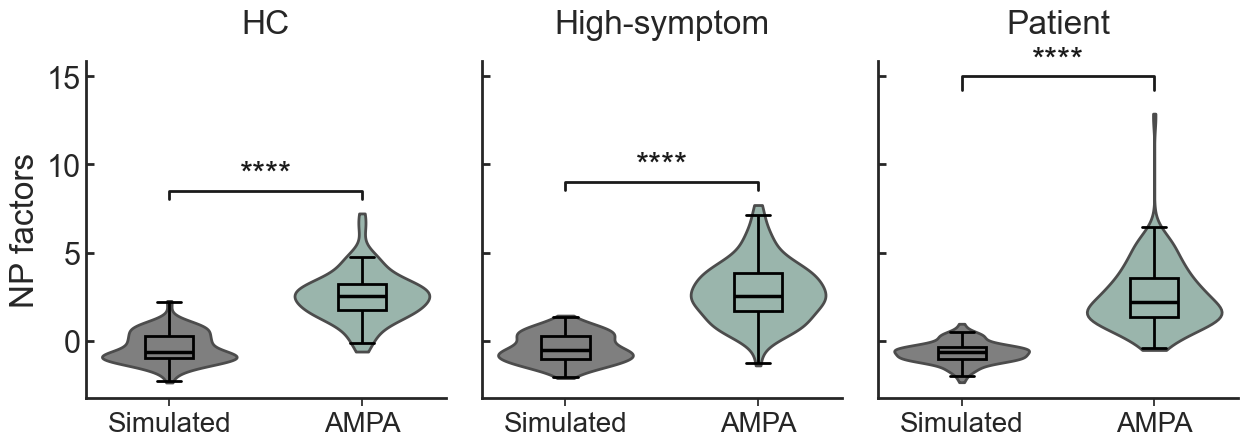

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel  # 建议使用配对T检验，因为模拟值是基于同一个体生成的

# 1. 数据加载与预处理
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/mani_ampa_gaba_subs3.csv')

# 这里的 palette 对应的是变量名
palette = {
    'Simulated NP': (127/255, 127/255, 127/255),       # 灰色代表真实值
    'Manipulated_gaba_with_high_ampa_np': (150/255, 185/255, 173/255) # 橙色代表模拟值
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks")
plt.rcParams['font.sans-serif'] = ['Arial']

def draw_internal_comparison(ax, df_group, group_name):
    """
    针对单个组绘制 np vs simulate np 的比较
    """
    # 将数据从宽表转为长表 (Melt)
    # 假设列名就是 'np' 和 'simulate np'
    df_melt = df_group.melt(value_vars=['Simulated NP','Manipulated_gaba_with_high_ampa_np'], 
                            var_name='Type', value_name='Score')

    # 绘制小提琴图
    sns.violinplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_gaba_with_high_ampa_np'],
                   palette=palette, inner=None, linewidth=2, cut=0.2, width=0.7, ax=ax)
    
    # 叠加箱线图
    sns.boxplot(data=df_melt, x='Type', y='Score', order=['Simulated NP','Manipulated_gaba_with_high_ampa_np'],
                width=0.25, showcaps=True, showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(color='black', linewidth=2),
                capprops=dict(color='black', linewidth=2), ax=ax)

    # 统计计算 (因为是同一个人的模拟，建议用配对 T 检验 ttest_rel)
    v1 = df_group['Simulated NP'].dropna()
    v2 = df_group['Manipulated_gaba_with_high_ampa_np'].dropna()
    stat, p_val = ttest_rel(v1, v2)
    
    # 显著性标注
    if p_val < 0.0001: sig_text = "****"
    elif p_val < 0.001: sig_text = "***"
    elif p_val < 0.01: sig_text = "**"
    elif p_val < 0.05: sig_text = "*"
    else: sig_text = "n.s."
    # --- 打印统计结果到控制台 ---
    print(f"{'='*10} Statistical Report: {group_name} {'='*10}")
    
    print(f"Paired T-test: t = {stat:.4f}, p = {p_val:.4f}")
    # 标注线高度控制
    y_max = df_melt['Score'].max()
    line_y = y_max + (df_melt['Score'].max() - df_melt['Score'].min()) * 0.1
    line_h = (df_melt['Score'].max() - df_melt['Score'].min()) * 0.05
    
    ax.plot([0, 0, 1, 1], [line_y, line_y + line_h, line_y + line_h, line_y], lw=2, c='k')
    ax.text(0.5, line_y + line_h, sig_text, ha='center', va='bottom', color='k', fontsize=24)

    # 细节美化
    ax.set_title(group_name, fontsize=24, pad=20)
    ax.set_ylabel('NP factors', fontsize=24)
    ax.set_xlabel('')
    ax.set_xticklabels(['Simulated', 'AMPA'], fontsize=20)
    ax.tick_params(axis='y', direction='in', length=6, width=2)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

# 2. 获取三个组的名字 (假设 Group 列里有三个唯一值)
group_list = df['Group'].unique() 
# 如果你想手动指定顺序，可以写成 group_list = ['HC', 'High-symptom', 'Patient']

# 3. 创建画布并循环绘图
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True) # sharey=True 方便横向对比

for i, g_name in enumerate(group_order):
    if i < 3: # 确保不超过子图数量
        df_sub = df[df['Group'] == g_name]
        draw_internal_comparison(axes[i], df_sub, g_name)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_simu_mani_gaba_3groups.png', dpi=300)
plt.show()

Statistics: U=1014.0, p-value=0.0000, n1=257, n2=33


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/795646039.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='group', y='Score_simulation',
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/795646039.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Increased','Decreased'], rotation=30)


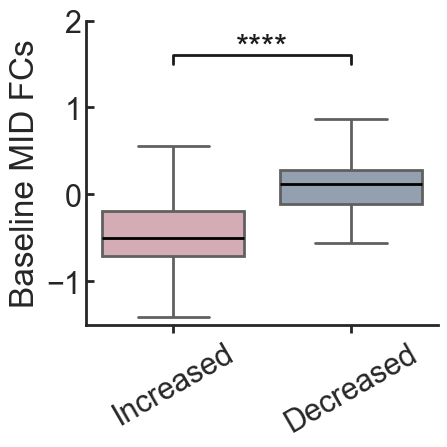

In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv('/Users/yunman/Desktop/submission/final_file/validation_mid_fcs.csv')
df_sub = df[df['group'].isin(['subgroup1', 'subgroup2'])]

# 参数
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (4, 5)})
group_order = ['subgroup1', 'subgroup2']
color_map = {
    'subgroup1': '#D9A5B3',
    'subgroup2': '#8DA0B4'}

# 绘图
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_sub, x='group', y='Score_simulation',
            dodge=False, palette=color_map, order=group_order, ax=ax, linewidth=2, showfliers=False,
           boxprops=dict(linewidth=2),
           whiskerprops=dict(linewidth=2),
           capprops=dict(linewidth=2),
           medianprops=dict(
           linewidth=0,
           color='black',
           zorder=10),
           )
colA='subgroup1';
colB='subgroup2';
 # 获取数据并直接 dropna (不考虑缺失值参与统计)
data1 = df_sub[df_sub['group'] == 'subgroup1']['Score_simulation'].dropna()
data2 = df_sub[df_sub['group'] == 'subgroup2']['Score_simulation'].dropna()

stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
print(f"Statistics: U={stat:.1f}, p-value={p:.4f}, n1={len(data1)}, n2={len(data2)}")

# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['group'] == g]['Score_simulation'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.4,
        xmax=i + 0.4,
        colors='black',
        linewidth=2,
        zorder=10
    )
sns.despine()
ax.set_xticklabels(['Increased','Decreased'], rotation=30)
ax.set_ylabel('Baseline MID FCs')
ax.set_xlabel('')
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y', direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(2)
# 添加显著性星号
group1 = df[df['group'] == 'subgroup1']['Score_simulation']
group2 = df[df['group'] == 'subgroup2']['Score_simulation']

# 比如你想在组1和组2之间画线
x1, x2 = 0, 1      # 两组在x轴上的位置（对应 Group2=1 和 Group2=2）
y = 1.5             # 横线的位置（y坐标）
h = 0.1            # 横线和星号之间的高度间隔
# 画横线
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
# 添加显著性标注（例如星号）
ax.text((x1+x2)*.5, y+h-0.1, "****", ha='center', va='bottom', color='k', fontsize=24)

# 调整y最大值
plt.ylim(-1.5,2)
ax.set_yticks([-1,0,1,2])
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/compare_simulated_baseline_mid.png',
            dpi=300, bbox_inches='tight')
plt.show()


In [147]:
df_sub

,Subject,Condition,Score,Group,Group2,Group3,Unnamed: 6,Condition.1,Score.1,Group.1,...,Condition.2,Score.2,Group.2,Group2.2,Group3.2,Unnamed: 18,Unnamed: 19,ampa_changes,gaba_changes,group
0,458976,Simulated,-0.884060,1,1,1,NaN,AMPA,0.060644,1,...,GABA-A,2.003419,1,1,1,NaN,NaN,0.944704,2.887479,subgroup1
1,829055,Simulated,-0.862785,1,1,1,NaN,AMPA,0.517743,1,...,GABA-A,1.182857,1,1,1,NaN,NaN,1.380528,2.045642,subgroup1
2,1647364,Simulated,-0.562043,1,1,1,NaN,AMPA,-0.432708,1,...,GABA-A,0.289054,1,1,1,NaN,NaN,0.129334,0.851097,subgroup1
3,2190836,Simulated,-0.288597,1,1,1,NaN,AMPA,-0.124271,1,...,GABA-A,0.326787,1,1,1,NaN,NaN,0.164326,0.615384,subgroup1
4,2270310,Simulated,1.003790,3,3,1,NaN,AMPA,0.767213,3,...,GABA-A,2.809126,3,3,1,NaN,NaN,-0.236577,1.805335,subgroup2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,195629783,Simulated,-0.476825,1,1,1,NaN,AMPA,0.128801,1,...,GABA-A,0.852039,1,1,1,NaN,NaN,0.605626,1.328864,subgroup1
286,195966822,Simulated,-0.551181,1,1,1,NaN,AMPA,0.852387,1,...,GABA-A,0.983795,1,1,1,NaN,NaN,1.403569,1.534976,subgroup1
287,197382673,Simulated,-0.883670,1,1,1,NaN,AMPA,-0.029040,1,...,GABA-A,-0.096764,1,1,1,NaN,NaN,0.854630,0.786905,subgroup1
288,198118454,Simulated,-0.658309,1,1,1,NaN,AMPA,0.426181,1,...,GABA-A,1.340937,1,1,1,NaN,NaN,1.084490,1.999246,subgroup1


Mann–Whitney U test p-value: 3.6929e-258
Mann–Whitney U test stat: 9.7196e+05


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/1230131827.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Correlation', order=['Within', 'Between'],
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_1798/1230131827.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Self-self', 'Self-other'])


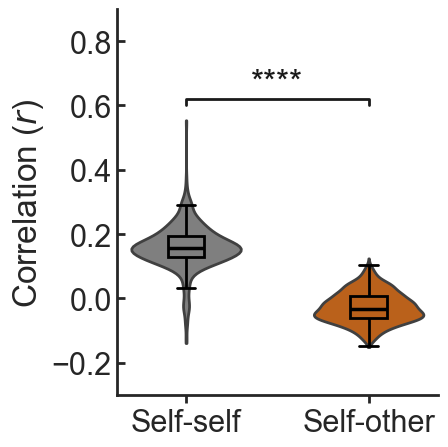

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu # 沿用你第一个脚本的非参数检验
import pandas as pd

# 1. 加载数据
file_path = '/Users/yunman/Desktop/submission/final_file/corr_simulate_self_and_other_empirical_activ_4subs_12_trials_bootstrap.csv'
df_raw = pd.read_csv(file_path)

# --- 核心转换：将宽表转为长表以匹配第二个脚本的逻辑 ---
within_vals = df_raw['all_within'].dropna()
between_vals = df_raw['all_between'].dropna()

df = pd.DataFrame({
    'Correlation': np.concatenate([within_vals, between_vals]),
    'Group': ['Within']*len(within_vals) + ['Between']*len(between_vals)
})

# 2. 配色与风格设置
palette = {
    'Within': (127/255, 127/255, 127/255),  # 灰色
    'Between': (213/255, 94/255, 0/255)     # 橙色
}

sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")

# 3. 绘制 Violin plot (背景)
ax = sns.violinplot(data=df, x='Group', y='Correlation', order=['Within', 'Between'],
                    palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)

# 4. 绘制 Boxplot (上层)
sns.boxplot(
    data=df, x='Group', y='Correlation', order=['Within', 'Between'],
    width=0.2, showcaps=True, showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)

# 5. 视觉优化
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y', direction='in')

# 6. 统计计算与标注
stat, p = mannwhitneyu(within_vals, between_vals, alternative='greater')
print(f'Mann–Whitney U test p-value: {p:.4e}')
print(f'Mann–Whitney U test stat: {stat:.4e}')
# 显著性标注逻辑
if p < 0.0001: sig_text = "****"
elif p < 0.001: sig_text = "***"
elif p < 0.01: sig_text = "**"
elif p < 0.05: sig_text = "*"
else: sig_text = "n.s."

# 自动计算标注线位置
y_top = df['Correlation'].max()
y_line = y_top + 0.05
h = 0.02

# 画横线
ax.plot([0, 0, 1, 1], [y_line, y_line+h, y_line+h, y_line], lw=2, c='k')
# 添加星号或 n.s.
ax.text(0.5, y_line+h, sig_text, ha='center', va='bottom', color='k', fontsize=24)

# 7. 坐标轴最终调整
ax.set_ylim(-0.3, 0.9)  # 根据相关系数的范围调整
ax.set_yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8])
plt.ylabel('Correlation ($r$)', fontsize=24)
plt.xlabel('')
ax.set_xticklabels(['Self-self', 'Self-other'])

for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/SI_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

Correlation Matrix Shape: (24, 4)
Label Matrix Shape: (24, 4)


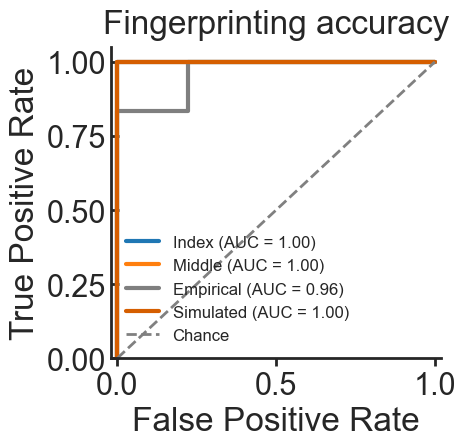

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
# 1. 加载数据
# 确保 header=None，这样 Pandas 不会跳过第一行
corr_df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/cross_validation/finger_predic_empir.csv', header=None)
y_true_df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/cross_validation/label_file.csv', header=None)

# 转换为 numpy 数组
corr_matrix = corr_df.values  # 应该是 (24, 4)
y_one_hot = y_true_df.values  # 应该是 (24, 4)，既然你已经是 24*4 的格式了

# --- 关键检查：打印形状以防万一 ---
print(f"Correlation Matrix Shape: {corr_matrix.shape}") # 必须是 (24, 4)
print(f"Label Matrix Shape: {y_one_hot.shape}")         # 必须是 (24, 4)

n_classes = 4
finger_names = ['Index', 'Middle', 'Empirical', 'Simulated']
colors = ['#1f77b4', '#ff7f0e', '#7F7F7F', '#D55E00']

# 2. 计算每一类的 ROC 和 AUC
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(n_classes):
    # 直接取第 i 列进行计算
    # y_one_hot[:, i] 是真实的 0/1 标签
    # corr_matrix[:, i] 是对应的预测得分
    fpr[i], tpr[i], _ = roc_curve(y_one_hot[:, i], corr_matrix[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. 绘图
plt.figure(figsize=(5, 5))
sns.set_style("ticks")

for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=3,
             label=f'{finger_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Chance')

# 4. 细节美化
plt.xlim([-0.02, 1.02])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fingerprinting accuracy', pad=10)
plt.legend(loc="best", frameon=False, fontsize=12)

sns.despine()
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y', direction='in')
plt.tight_layout()
# 自动保存
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/cross_validation/finger_ROC_final.png', dpi=300)
plt.show()